# Exploratory Data Analysis for PPG features

changes in blood volume using an optical sensor (typically on a finger or wrist), making it useful for estimating heart activity and autonomic nervous system responses

In [1]:
import pickle

def read_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f)
        return data

In [2]:
path = "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/arithmetix_easy/PPG_features_30_sec.pickle"

In [3]:
PPG_30 = read_file(path)

In [4]:
PPG_30.head()

,Std_HR,Mean_HR,HRV_MeanNN,HRV_SDNN,HRV_RMSSD
0,20.865291,80.492527,762.335526,257.902904,345.253545
1,22.728859,79.584648,737.580128,222.627162,325.786624
2,21.328757,75.890562,767.680921,265.567140,344.698859
3,21.895427,75.531046,744.391026,226.015594,308.943579
4,19.081117,83.246558,750.000000,238.961320,334.113231


In [5]:
PPG_30.columns

Index(['Std_HR', 'Mean_HR', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD'], dtype='object')

In [6]:
for column in PPG_30.columns:
    #print data type of column
    print(f"{column}: {PPG_30[column].dtype}")

Std_HR: float64
Mean_HR: float64
HRV_MeanNN: float64
HRV_SDNN: float64
HRV_RMSSD: float64


In [7]:
PPG_30.describe()

,Std_HR,Mean_HR,HRV_MeanNN,HRV_SDNN,HRV_RMSSD
count,96.000000,96.000000,96.000000,96.000000,96.000000
mean,15.381774,81.714765,743.488880,180.945426,248.686906
std,4.157305,3.986602,29.904169,64.424236,87.955636
min,4.116850,72.170664,690.104167,42.992466,62.190847
25%,13.194555,78.589668,722.735324,134.343559,188.895290
50%,15.271935,82.606910,736.979167,170.042738,239.401802
75%,18.492338,84.832112,759.971217,222.637520,321.298097
max,24.077302,89.164269,821.875000,349.901978,515.039775


array([[<Axes: title={'center': 'Std_HR'}>,
        <Axes: title={'center': 'Mean_HR'}>],
       [<Axes: title={'center': 'HRV_MeanNN'}>,
        <Axes: title={'center': 'HRV_SDNN'}>],
       [<Axes: title={'center': 'HRV_RMSSD'}>, <Axes: >]], dtype=object)

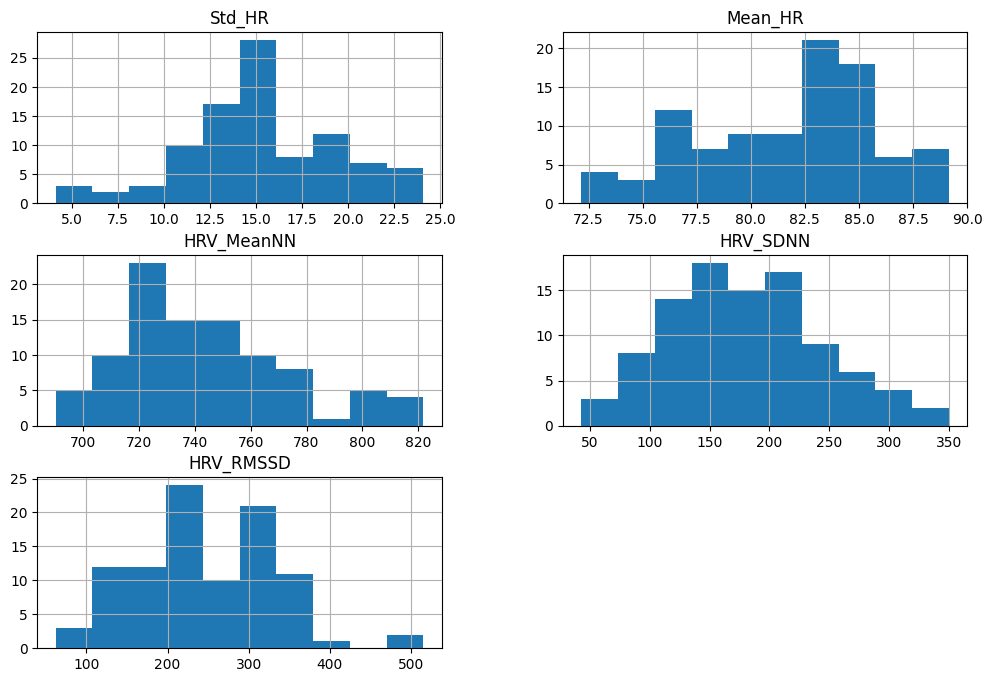

In [8]:
PPG_30.hist(figsize=(12,8))

In [ ]:
import os
import pickle
import pandas as pd


base_path = "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress"

patient_ids = ["140", "141", "247", "257", "260","313","362","404","437","446","491"]


tasks = {
    "arithmetix_easy": "easy",
    "arithmetix_hard": "hard",
    "relaxation_video": "relaxation"
}

feature_columns = ['Std_HR', 'Mean_HR', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']

def read_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

all_data = []

for patient_id in patient_ids:

    for task_folder, task_label in tasks.items():

        path = os.path.join(
            base_path,
            "ES"+patient_id,
            "Lab",
            "Features",
            task_folder,
            "PPG_features_30_sec.pickle"
        )

        
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue

        
        df = read_pickle(path).copy()

       
        df = df[feature_columns].copy()

       
        df["task_label"] = task_label
        df["patient_id"] = patient_id

        all_data.append(df)

        print(
            f"{patient_id} | {task_label} | "
            f"{df.shape[0]} windows"
        )


PPG_all = pd.concat(
    all_data,
    ignore_index=True
)

print("\nFinal shape:", PPG_all.shape)

PPG_all.head()